In [1]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
columns = [
    'Status', 'Duration', 'CreditHistory', 'Purpose', 'CreditAmount',
    'Savings', 'Employment', 'InstallmentRate', 'PersonalStatus',
    'OtherDebtors', 'ResidenceSince', 'Property', 'Age',
    'OtherInstallmentPlans', 'Housing', 'ExistingCredits',
    'Job', 'Dependents', 'Telephone', 'ForeignWorker', 'Target'
]
df = pd.read_csv(url, sep=' ', names=columns)
df['Target'] = df['Target'].map({1: 0, 2: 1})
df.head()

,Status,Duration,CreditHistory,Purpose,CreditAmount,Savings,Employment,InstallmentRate,PersonalStatus,OtherDebtors,...,Property,Age,OtherInstallmentPlans,Housing,ExistingCredits,Job,Dependents,Telephone,ForeignWorker,Target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


In [5]:
df.shape

(1000, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Status                 1000 non-null   object
 1   Duration               1000 non-null   int64 
 2   CreditHistory          1000 non-null   object
 3   Purpose                1000 non-null   object
 4   CreditAmount           1000 non-null   int64 
 5   Savings                1000 non-null   object
 6   Employment             1000 non-null   object
 7   InstallmentRate        1000 non-null   int64 
 8   PersonalStatus         1000 non-null   object
 9   OtherDebtors           1000 non-null   object
 10  ResidenceSince         1000 non-null   int64 
 11  Property               1000 non-null   object
 12  Age                    1000 non-null   int64 
 13  OtherInstallmentPlans  1000 non-null   object
 14  Housing                1000 non-null   object
 15  ExistingCredits       

In [8]:
df.isnull().sum()

,0
Status,0
Duration,0
CreditHistory,0
Purpose,0
CreditAmount,0
Savings,0
Employment,0
InstallmentRate,0
PersonalStatus,0
OtherDebtors,0


In [9]:
df["Target"].value_counts()

,count
Target,
0,700
1,300


In [10]:
df["Target"].value_counts(normalize=True)


,proportion
Target,
0,0.7
1,0.3


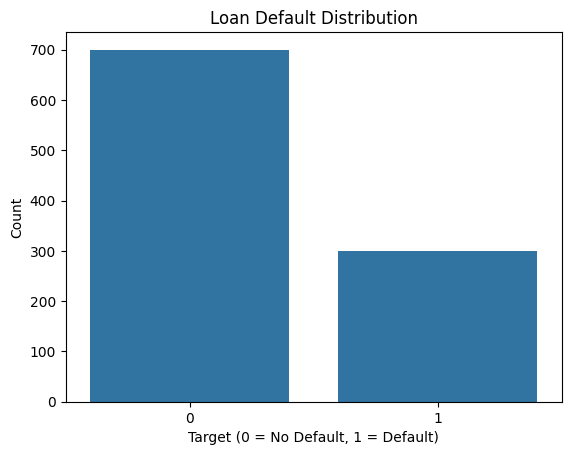

In [14]:
sns.countplot(x='Target', data=df)
plt.title("Loan Default Distribution")
plt.xlabel("Target (0 = No Default, 1 = Default)")
plt.ylabel("Count")
plt.show()


In [15]:
X = df.drop('Target', axis=1)
y = df['Target']
X.shape, y.shape

((1000, 20), (1000,))

In [16]:
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols =X.select_dtypes(exclude='object').columns
categorical_cols, numerical_cols

(Index(['Status', 'CreditHistory', 'Purpose', 'Savings', 'Employment',
        'PersonalStatus', 'OtherDebtors', 'Property', 'OtherInstallmentPlans',
        'Housing', 'Job', 'Telephone', 'ForeignWorker'],
       dtype='object'),
 Index(['Duration', 'CreditAmount', 'InstallmentRate', 'ResidenceSince', 'Age',
        'ExistingCredits', 'Dependents'],
       dtype='object'))

In [17]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X_encoded.shape

(1000, 48)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train.shape, X_test.shape

((800, 48), (200, 48))

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [21]:
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       140
           1       0.66      0.58      0.62        60

    accuracy                           0.79       200
   macro avg       0.75      0.73      0.73       200
weighted avg       0.78      0.79      0.78       200



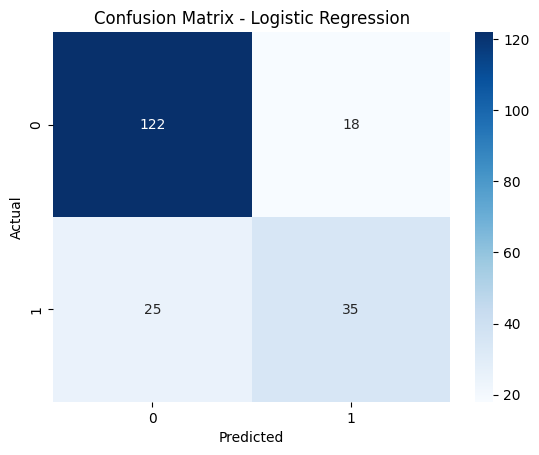

In [24]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [25]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
roc_auc

np.float64(0.7999999999999999)

In [26]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [31]:
y_pred_rf = rf_model.predict(X_test)
y_pred_rf_proba = rf_model.predict_proba(X_test)[:, 1]

In [32]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82       140
           1       0.59      0.50      0.54        60

    accuracy                           0.74       200
   macro avg       0.69      0.68      0.68       200
weighted avg       0.74      0.74      0.74       200



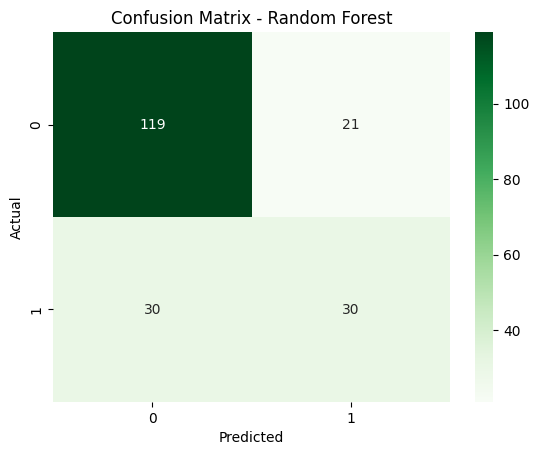

In [33]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()


In [34]:
roc_auc_rf = roc_auc_score(y_test, y_pred_rf_proba)
roc_auc_rf

np.float64(0.7992857142857142)

In [35]:
y_prob_lr = y_pred_proba

In [37]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_prob_lr >= t).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred_t, average='binary'
    )
    results.append([t, precision, recall, f1])

results_df = pd.DataFrame(
    results,
    columns=['Threshold', 'Precision', 'Recall', 'F1']
)

results_df


,Threshold,Precision,Recall,F1
0,0.10,0.375000,0.900000,0.529412
1,0.15,0.419355,0.866667,0.565217
2,0.20,0.476190,0.833333,0.606061
3,0.25,0.505155,0.816667,0.624204
4,0.30,0.550562,0.816667,0.657718
5,0.35,0.589744,0.766667,0.666667
6,0.40,0.626866,0.700000,0.661417
7,0.45,0.620690,0.600000,0.610169
8,0.50,0.660377,0.583333,0.619469
9,0.55,0.682927,0.466667,0.554455


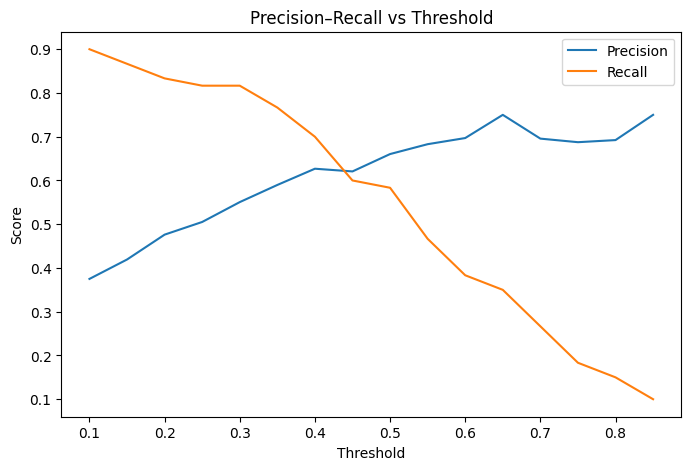

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(results_df['Threshold'], results_df['Precision'], label='Precision')
plt.plot(results_df['Threshold'], results_df['Recall'], label='Recall')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall vs Threshold")
plt.legend()
plt.show()

In [39]:
best_threshold = 0.35

y_pred_custom = (y_prob_lr >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.89      0.77      0.82       140
           1       0.59      0.77      0.67        60

    accuracy                           0.77       200
   macro avg       0.74      0.77      0.75       200
weighted avg       0.80      0.77      0.78       200



In [40]:
feature_names = X_encoded.columns

In [41]:
coefficients = log_reg.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

feature_importance.head()

,Feature,Coefficient
0,Duration,0.329732
1,CreditAmount,0.344474
2,InstallmentRate,0.391767
3,ResidenceSince,0.014211
4,Age,-0.052506


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Coefficient'].plot(kind='hist', bins=20, title='Coefficient')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_2.groupby('Feature').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3.plot(kind='scatter', x='index', y='Coefficient', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_7['Coefficient'].plot(kind='line', figsize=(8, 4), title='Coefficient')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_8['Feature'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_8, x='index', y='Feature', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_9['Feature'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_9, x='Coefficient', y='Feature', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [42]:
feature_importance['AbsCoeff'] = feature_importance['Coefficient'].abs()
feature_importance_sorted = feature_importance.sort_values(
    by='AbsCoeff', ascending=False
)

feature_importance_sorted.head(10)

,Feature,Coefficient,AbsCoeff
9,Status_A14,-0.782411,0.782411
13,CreditHistory_A34,-0.639586,0.639586
32,PersonalStatus_A93,-0.482885,0.482885
38,Property_A124,0.453083,0.453083
42,Housing_A153,-0.438921,0.438921
26,Savings_A65,-0.427092,0.427092
14,Purpose_A41,-0.402584,0.402584
2,InstallmentRate,0.391767,0.391767
29,Employment_A74,-0.370712,0.370712
1,CreditAmount,0.344474,0.344474


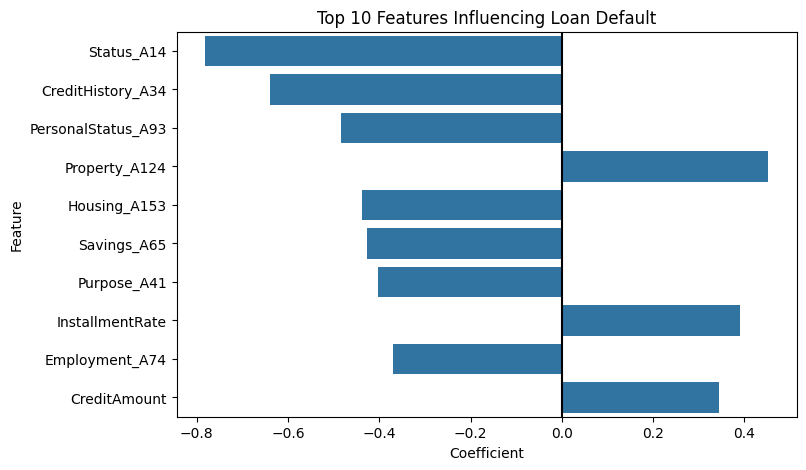

In [43]:
top_features = feature_importance_sorted.head(10)

plt.figure(figsize=(8, 5))
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=top_features
)
plt.title("Top 10 Features Influencing Loan Default")
plt.axvline(0, color='black')
plt.show()